In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_excel("flood dataset.xlsx")
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [4]:
dataset.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [5]:
dataset.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

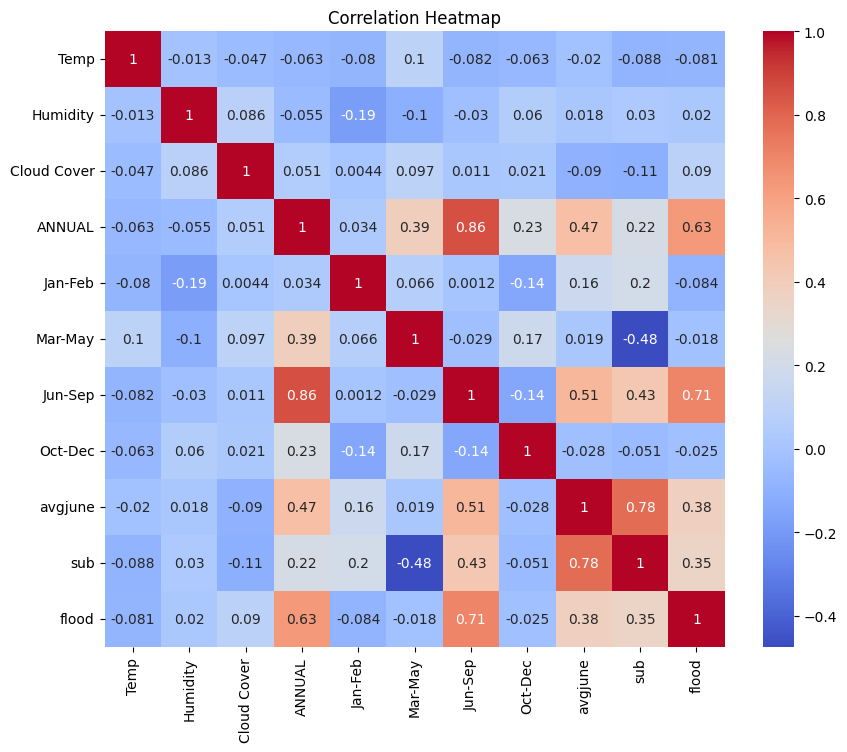

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

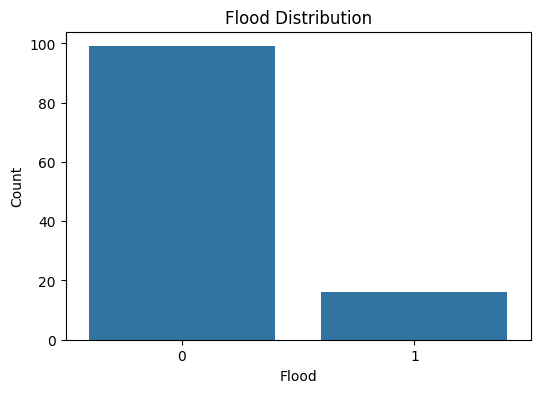

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='flood', data=dataset)
plt.title("Flood Distribution")
plt.xlabel("Flood")
plt.ylabel("Count")
plt.show()

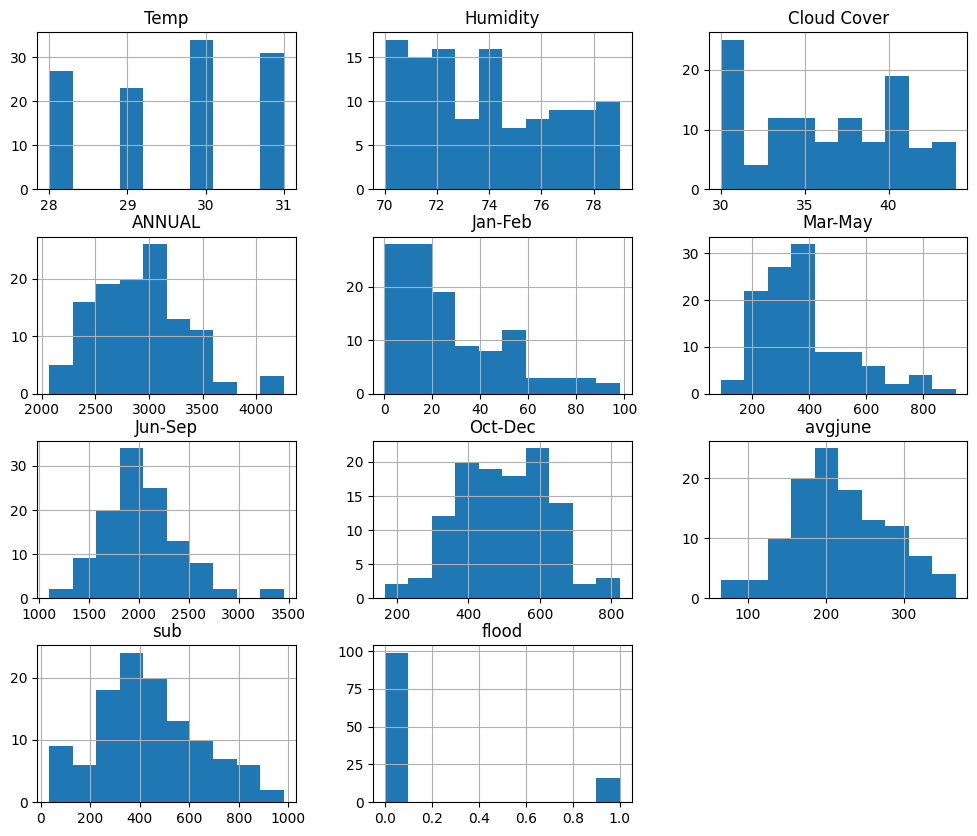

In [8]:
dataset.hist(figsize=(12,10))
plt.show()

In [9]:
X = dataset.drop('flood', axis=1)
y = dataset['flood']

print(X.head())
print(y.head())

   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  
0  274.866667  649.9  
1  130.300000  256.4  
2  186.200000  308.9  
3  366.066667  862.5  
4  283.400000  586.9  
0    0
1    1
2    0
3    0
4    0
Name: flood, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(92, 10)
(23, 10)


In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


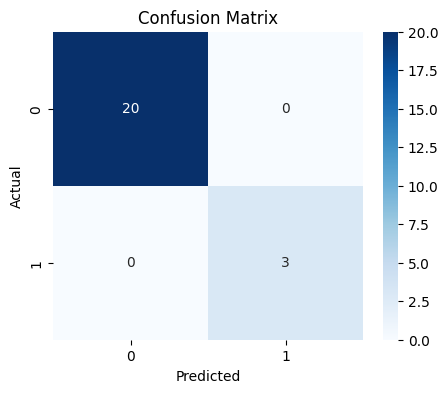

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [15]:
sample = [[29, 70, 30, 3248.6, 73.4, 386.2, 2122.8, 666.1, 274.86, 649.9]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Flood Predicted")
else:
    print("No Flood Predicted")


No Flood Predicted


c:\Users\Shaik Farida\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [16]:
import pandas as pd

sample = pd.DataFrame(
    [[29, 70, 30, 3248.6, 73.4, 386.2, 2122.8, 666.1, 274.86, 649.9]],
    columns=X.columns
)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Flood Predicted")
else:
    print("No Flood Predicted")

No Flood Predicted


In [17]:
#Epic 3
dataset.isnull().any()

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

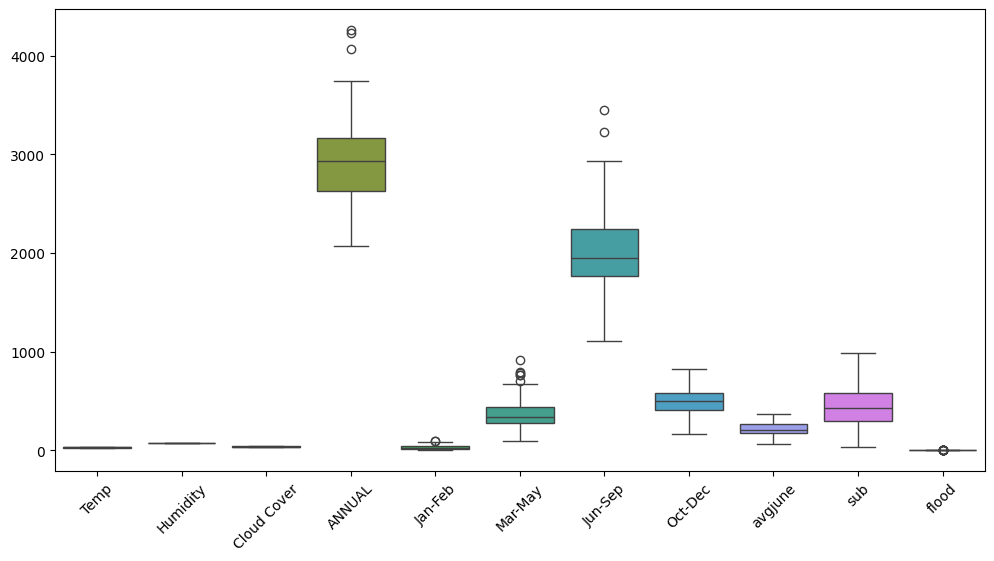

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=dataset)
plt.xticks(rotation=45)
plt.show()

In [19]:
dataset.dtypes

Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

In [20]:
from sklearn.model_selection import train_test_split



X = dataset.drop('flood', axis=1)

y = dataset['flood']



X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, random_state=42

)
print("Training Set:",X_train.shape)
print("Testing Set:",X_test.shape)

Training Set: (92, 10)
Testing Set: (23, 10)


In [21]:
from sklearn.preprocessing import StandardScaler

# Create the StandardScaler object
sc = StandardScaler()

# Scale the training data
X_train = sc.fit_transform(X_train)

# Scale the testing data
X_test = sc.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [22]:
##Epic 4
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
dt_model = DecisionTreeClassifier(random_state=42)

In [24]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
y_pred_dt = dt_model.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Accuracy: 1.0

Confusion Matrix:
[[20  0]
 [ 0  3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [29]:
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf = rf_model.predict(X_test)


In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0

Confusion Matrix:
[[20  0]
 [ 0  3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [32]:
from sklearn.neighbors import KNeighborsClassifier


In [33]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [34]:
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [35]:
y_pred_knn = knn_model.predict(X_test)

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.9130434782608695

Confusion Matrix:
[[20  0]
 [ 2  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.33      0.50         3

    accuracy                           0.91        23
   macro avg       0.95      0.67      0.73        23
weighted avg       0.92      0.91      0.89        23



In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def xgboost(X_train, X_test, y_train, y_test):

    print("========== XGBOOST MODEL BUILDING ==========")

    model = GradientBoostingClassifier()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    print("Accuracy:", accuracy)
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(cr)

    return model, y_pred

xgb_model, xgb_pred = xgboost(X_train, X_test, y_train, y_test)

========== XGBOOST MODEL BUILDING ==========
Accuracy: 1.0
Confusion Matrix:
[[20  0]
 [ 0  3]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [38]:
from sklearn import metrics

print("Decision Tree Accuracy :", metrics.accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy :", metrics.accuracy_score(y_test, y_pred_rf))
print("KNN Accuracy           :", metrics.accuracy_score(y_test, y_pred_knn))
print("XGBoost Accuracy       :", metrics.accuracy_score(y_test, xgb_pred))

Decision Tree Accuracy : 1.0
Random Forest Accuracy : 1.0
KNN Accuracy           : 0.9130434782608695
XGBoost Accuracy       : 1.0


In [39]:
from sklearn import metrics
import joblib

print("Confusion Matrix:")
print(metrics.confusion_matrix(y_test, xgb_pred))

print("\nAccuracy Score:")
print(metrics.accuracy_score(y_test, xgb_pred))

print("\nPrecision Score:")
print(metrics.precision_score(y_test, xgb_pred))

print("\nRecall Score:")
print(metrics.recall_score(y_test, xgb_pred))

# Save final model
joblib.dump(xgb_model, "floods.save")

Confusion Matrix:
[[20  0]
 [ 0  3]]

Accuracy Score:
1.0

Precision Score:
1.0

Recall Score:
1.0


['floods.save']